In [1]:
!pip install cirq

In [3]:
import cirq
import numpy as np
import matplotlib.pyplot as plt

print(cirq.__version__)
print(np.__version__)

1.7.0
2.5.2


In [5]:
def plot_bloch(bloch_vec, title=''):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')

    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    x = np.cos(u) * np.sin(v)
    y = np.sin(u) * np.sin(v)
    z = np.cos(v)

    ax.plot_wireframe(x, y, z, color='lightgray', linewidth=0.5)

    ax.quiver(
        0, 0, 0,
        bloch_vec[0], bloch_vec[1], bloch_vec[2],
        color='red',
        linewidth=2,
        arrow_length_ratio=0.15
    )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

    plt.show()

Task 1.1

In [7]:
q = cirq.LineQubit(0)
sim = cirq.Simulator()

circuit1 = cirq.Circuit()

result1 = sim.simulate(
    circuit1,
    qubit_order=[q]
)

print(result1.final_state_vector)

[1.+0.j 0.+0.j]


Task 1.2 — Hadamard

In [8]:
circuit2 = cirq.Circuit(cirq.H(q))

result2 = sim.simulate(
    circuit2,
    qubit_order=[q]
)

print(result2.final_state_vector)
print('Probabilities:', np.abs(result2.final_state_vector) ** 2)

[0.70710677+0.j 0.70710677+0.j]
Probabilities: [0.49999997 0.49999997]


Task 1.3 — TODO

In [11]:
custom_state = np.array(
    [1/np.sqrt(2), 1j/np.sqrt(2)],
    dtype=complex
)

circuit3 = cirq.Circuit()

result3 = sim.simulate(
    circuit3,
    qubit_order=[q],
    initial_state=custom_state
)

print(result3.final_state_vector)

[0.70710677+0.j         0.        +0.70710677j]


Task 2.1

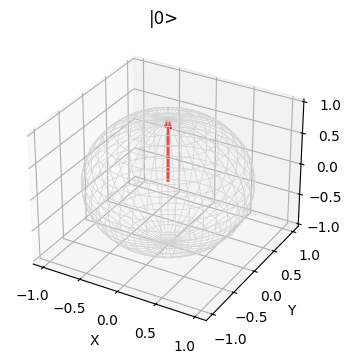

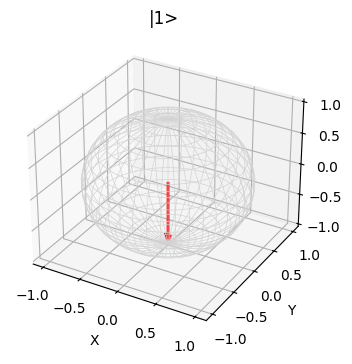

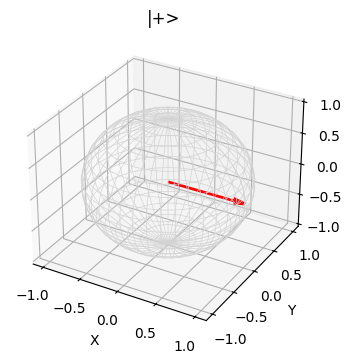

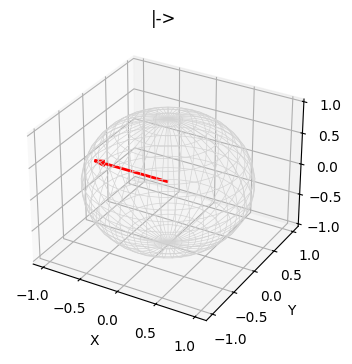

In [12]:
circuits = {
    '|0>': cirq.Circuit(),
    '|1>': cirq.Circuit(cirq.X(q)),
    '|+>': cirq.Circuit(cirq.H(q)),
    '|->': cirq.Circuit([cirq.X(q), cirq.H(q)]),
}

for name, circ in circuits.items():
    sv = sim.simulate(
        circ,
        qubit_order=[q]
    ).final_state_vector

    vec = cirq.bloch_vector_from_state_vector(sv, 0)

    plot_bloch(vec, title=name)

Task 2.2

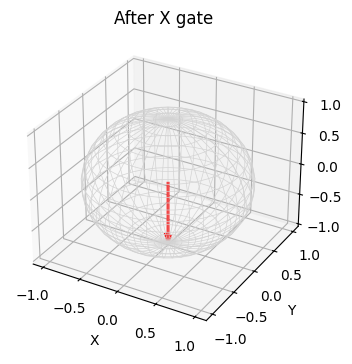

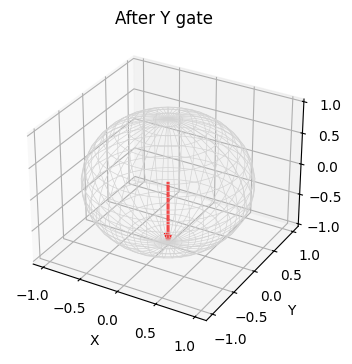

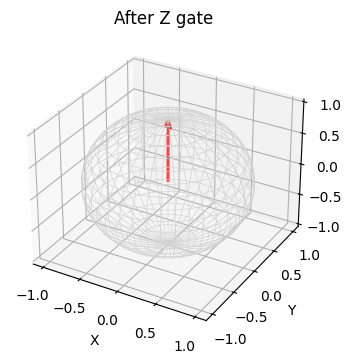

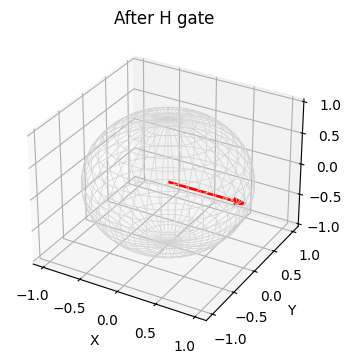

In [13]:
gates = {
    'X': cirq.X,
    'Y': cirq.Y,
    'Z': cirq.Z,
    'H': cirq.H
}

for name, gate in gates.items():
    circ = cirq.Circuit(gate(q))

    sv = sim.simulate(
        circ,
        qubit_order=[q]
    ).final_state_vector

    vec = cirq.bloch_vector_from_state_vector(sv, 0)

    plot_bloch(vec, title=f'After {name} gate')

Activity 3 — Quantum Gates

Task 3.1

In [14]:
single_gates = {
    'X': cirq.X,
    'Y': cirq.Y,
    'Z': cirq.Z,
    'H': cirq.H,
    'S': cirq.S,
    'T': cirq.T,
}

for name, gate in single_gates.items():
    print(name, 'matrix:')
    print(cirq.unitary(gate).round(3))

    circ = cirq.Circuit(gate(q))

    sv = sim.simulate(
        circ,
        qubit_order=[q]
    ).final_state_vector

    print(name, 'applied to |0>:', sv.round(4))
    print('-' * 40)

X matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X applied to |0>: [0.+0.j 1.+0.j]
----------------------------------------
Y matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y applied to |0>: [0.+0.j 0.+1.j]
----------------------------------------
Z matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z applied to |0>: [ 1.+0.j -0.+0.j]
----------------------------------------
H matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H applied to |0>: [0.7071+0.j 0.7071+0.j]
----------------------------------------
S matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S applied to |0>: [1.+0.j 0.+0.j]
----------------------------------------
T matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T applied to |0>: [1.+0.j 0.+0.j]
----------------------------------------


(a) H² = I

In [15]:
circuit_hh = cirq.Circuit([
    cirq.H(q),
    cirq.H(q)
])

(b) S² = Z

In [16]:
circuit_ss = cirq.Circuit([
    cirq.S(q),
    cirq.S(q)
])

(c) T² = S

In [17]:
circuit_tt = cirq.Circuit([
    cirq.T(q),
    cirq.T(q)
])

(d) H X H = Z


In [18]:
circuit_hxh = cirq.Circuit([
    cirq.H(q),
    cirq.X(q),
    cirq.H(q)
])

Task 3.3 — RX, RY, RZ

In [19]:
angles = {
    'pi/2': np.pi/2,
    'pi': np.pi
}

for name, theta in angles.items():
    for gate_fn, gname in [
        (cirq.rx, 'RX'),
        (cirq.ry, 'RY'),
        (cirq.rz, 'RZ')
    ]:
        circ = cirq.Circuit(gate_fn(theta)(q))

        sv = sim.simulate(
            circ,
            qubit_order=[q]
        ).final_state_vector

        probs = np.abs(sv) ** 2

        print(
            f'{gname}({name}) |0> = '
            f'{sv.round(4)} probs={probs.round(4)}'
        )

RX(pi/2) |0> = [0.7071+0.j     0.    -0.7071j] probs=[0.5 0.5]
RY(pi/2) |0> = [0.7071+0.j 0.7071+0.j] probs=[0.5 0.5]
RZ(pi/2) |0> = [0.7071-0.7071j 0.    +0.j    ] probs=[1. 0.]
RX(pi) |0> = [0.+0.j 0.-1.j] probs=[0. 1.]
RY(pi) |0> = [0.+0.j 1.+0.j] probs=[0. 1.]
RZ(pi) |0> = [0.-1.j 0.+0.j] probs=[1. 0.]


Task 3.4 — CNOT

In [20]:
q0, q1 = cirq.LineQubit.range(2)

for q0_val, q1_val in [
    (0, 0),
    (0, 1),
    (1, 0),
    (1, 1)
]:
    ops = []

    if q0_val:
        ops.append(cirq.X(q0))

    if q1_val:
        ops.append(cirq.X(q1))

    circuit = cirq.Circuit(
        ops + [cirq.CNOT(q0, q1)]
    )

    result = sim.simulate(
        circuit,
        qubit_order=[q0, q1]
    )

    print(
        f'Input |{q0_val}{q1_val}> -> '
        f'Output {result.dirac_notation()}'
    )

Input |00> -> Output |00⟩
Input |01> -> Output |01⟩
Input |10> -> Output |11⟩
Input |11> -> Output |10⟩


Task 3.5 — Bell State

In [21]:
bell_circuit = cirq.Circuit([
    cirq.H(q0),
    cirq.CNOT(q0, q1)
])

result = sim.simulate(
    bell_circuit,
    qubit_order=[q0, q1]
)

print(result.final_state_vector.round(4))
print(result.dirac_notation())

[0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
0.71|00⟩ + 0.71|11⟩


Activity 4 — Measurement

Task 4.1

In [22]:
circuit_m = cirq.Circuit([
    cirq.H(q),
    cirq.measure(q, key='result')
])

res = sim.run(
    circuit_m,
    repetitions=1024
)

print(res.histogram(key='result'))

Counter({1: 521, 0: 503})


Task 4.2

In [23]:
thetas = {
    '0': 0,
    'pi/4': np.pi/4,
    'pi/2': np.pi/2,
    '3pi/4': 3*np.pi/4,
    'pi': np.pi
}

for label, theta in thetas.items():

    circuit = cirq.Circuit([
        cirq.ry(theta)(q),
        cirq.measure(q, key='result')
    ])

    res = sim.run(
        circuit,
        repetitions=1024
    )

    hist = res.histogram(key='result')

    p1_sim = hist[1] / 1024

    p1_theory = np.sin(theta / 2) ** 2

    print(
        f'theta={label:5s} '
        f'hist={dict(hist)} '
        f'P(1)_sim={p1_sim:.3f} '
        f'P(1)_theory={p1_theory:.3f}'
    )

theta=0     hist={0: 1024} P(1)_sim=0.000 P(1)_theory=0.000
theta=pi/4  hist={0: 877, 1: 147} P(1)_sim=0.144 P(1)_theory=0.146
theta=pi/2  hist={1: 522, 0: 502} P(1)_sim=0.510 P(1)_theory=0.500
theta=3pi/4 hist={1: 866, 0: 158} P(1)_sim=0.846 P(1)_theory=0.854
theta=pi    hist={1: 1024} P(1)_sim=1.000 P(1)_theory=1.000


Task 4.3

In [24]:
circuit_plus = cirq.Circuit([
    cirq.H(q),
    cirq.measure(q, key='result')
])

for shots in [100, 1024, 8192]:

    res = sim.run(
        circuit_plus,
        repetitions=shots
    )

    print(
        f'shots={shots}:',
        dict(res.histogram(key='result'))
    )

shots=100: {1: 44, 0: 56}
shots=1024: {0: 501, 1: 523}
shots=8192: {1: 4164, 0: 4028}


Task 4.4 — Bell measurement

In [25]:
import collections

bell_m = cirq.Circuit([
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1, key='result')
])

res = sim.run(
    bell_m,
    repetitions=1024
)

bits = res.measurements['result']

strs = [
    ''.join(str(b) for b in row)
    for row in bits
]

print(collections.Counter(strs))

Counter({'00': 546, '11': 478})
